In [1]:
import pandas as pd
from pycaret.regression import *
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import optunahub
import optuna

from sklearn.preprocessing import PowerTransformer

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [3]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [17]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

In [ ]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [62]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)


xG
0.000000    4082
0.034354       2
0.084468       2
0.014015       2
0.019109       2
            ... 
0.032757       1
0.115458       1
0.086272       1
0.027934       1
0.405868       1
Name: count, Length: 2351, dtype: int64


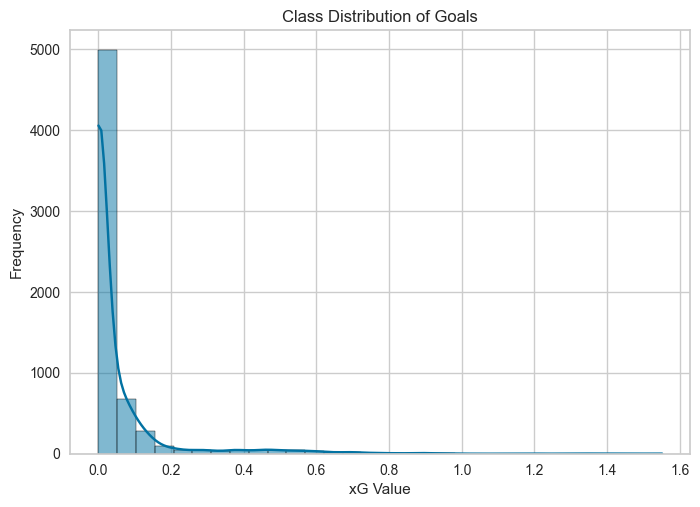

In [64]:
print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

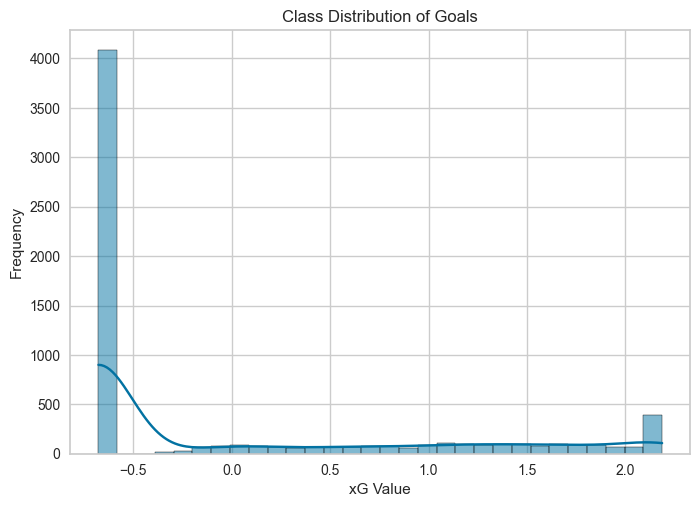

In [65]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xg_data[['xG']])

def_xg_data['xG'] = pt.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [66]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5892
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 86
[LightGBM] [Info] Start training from score -0.004189


,Description,Value
0,Session id,773
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6455, 147)"
4,Transformed data shape,"(6455, 30)"
5,Transformed train set shape,"(5164, 30)"
6,Transformed test set shape,"(1291, 30)"
7,Numeric features,145
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3186,0.2921,0.5400,0.7088,0.2448,1.6716,1.8880
rf,Random Forest Regressor,0.3194,0.2952,0.5427,0.7057,0.2440,1.8444,3.7450
lightgbm,Light Gradient Boosting Machine,0.3271,0.3005,0.5477,0.7005,0.2463,1.5677,0.9070
gbr,Gradient Boosting Regressor,0.3367,0.2977,0.5453,0.7031,0.2525,1.5872,1.7060
xgboost,Extreme Gradient Boosting,0.3577,0.3331,0.5767,0.6675,0.2487,1.7188,1.0520
ada,AdaBoost Regressor,0.3685,0.3252,0.5700,0.6756,0.2381,1.8639,0.9230
dt,Decision Tree Regressor,0.3786,0.5464,0.7381,0.4564,0.2683,1.8852,0.7890
huber,Huber Regressor,0.4398,0.5185,0.7196,0.4841,0.3258,1.5874,0.9030
knn,K Neighbors Regressor,0.4471,0.4791,0.6917,0.5225,0.3044,1.6820,0.6100
omp,Orthogonal Matching Pursuit,0.5171,0.4750,0.6888,0.5271,0.3547,1.4925,0.6650


ExtraTreesRegressor(n_jobs=-1, random_state=773)

In [67]:
evaluate_model(base_def_xg_best,)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

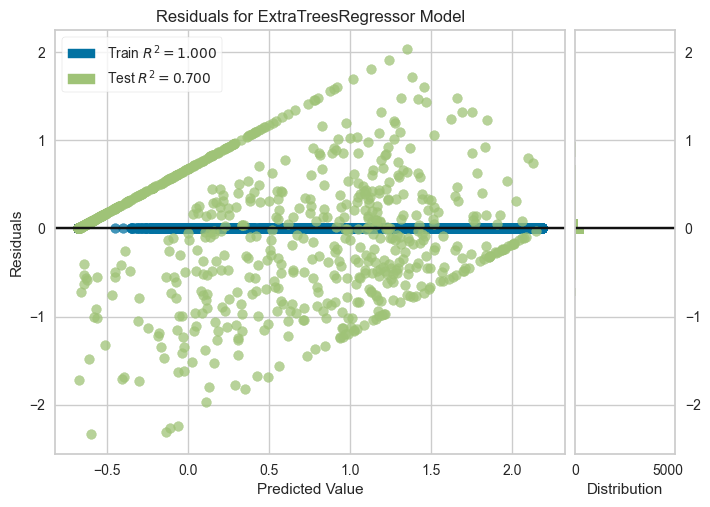

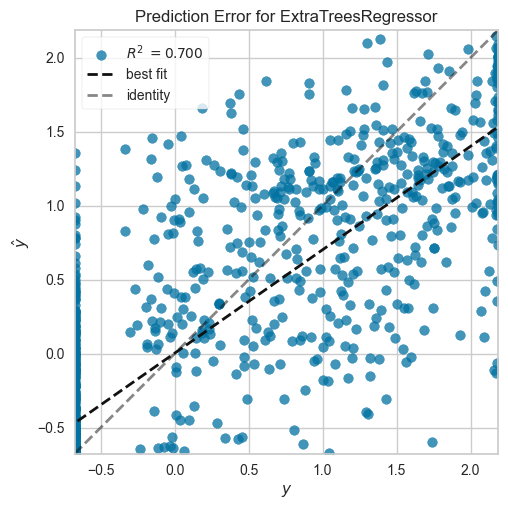

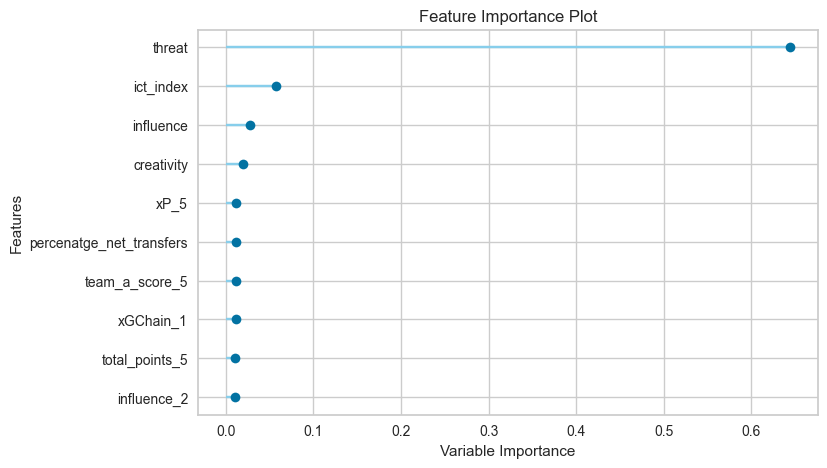

In [68]:
plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Blended Model


In [70]:
blend_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xg_best = compare_models(n_select=3, sort='MAE')
print(def_xg_best)

print('Blended model')
# Ensemble (blend or stack)
def_xg_blended = blend_models(def_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5844
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 86
[LightGBM] [Info] Start training from score 0.008468


,Description,Value
0,Session id,2563
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6455, 147)"
4,Transformed data shape,"(6455, 30)"
5,Transformed train set shape,"(5164, 30)"
6,Transformed test set shape,"(1291, 30)"
7,Numeric features,145
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3241,0.2981,0.5456,0.7042,0.2468,1.6921,2.1860
rf,Random Forest Regressor,0.3253,0.3026,0.5498,0.6998,0.2459,1.6847,3.8220
lightgbm,Light Gradient Boosting Machine,0.3390,0.3134,0.5593,0.6890,0.2524,1.5932,0.7980
gbr,Gradient Boosting Regressor,0.3440,0.3078,0.5544,0.6944,0.2540,1.6818,1.6960
xgboost,Extreme Gradient Boosting,0.3661,0.3430,0.5852,0.6597,0.2566,1.9496,1.0240
ada,AdaBoost Regressor,0.3791,0.3346,0.5782,0.6681,0.2429,1.5971,0.7930
dt,Decision Tree Regressor,0.3962,0.5879,0.7653,0.4168,0.2690,2.5648,0.9050
huber,Huber Regressor,0.4518,0.5264,0.7250,0.4783,0.3309,1.3400,0.7690
knn,K Neighbors Regressor,0.4680,0.5067,0.7109,0.4970,0.3127,1.8496,0.6840
ridge,Ridge Regression,0.5249,0.4842,0.6955,0.5200,0.3595,1.4095,0.5900


[ExtraTreesRegressor(n_jobs=-1, random_state=2563), RandomForestRegressor(n_jobs=-1, random_state=2563), LGBMRegressor(n_jobs=-1, random_state=2563)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3190,0.2819,0.5310,0.7107,0.2493,2.2129
1,0.3545,0.3238,0.5690,0.6825,0.2439,1.1481
2,0.3164,0.2958,0.5439,0.7239,0.2513,4.7332
3,0.3334,0.3004,0.5481,0.7198,0.2514,1.1532
4,0.3069,0.2814,0.5305,0.6825,0.2574,0.9389
5,0.3052,0.2611,0.5110,0.7403,0.2386,2.1436
6,0.3333,0.3207,0.5663,0.6904,0.2454,0.8224
7,0.3054,0.2709,0.5205,0.7364,0.2348,1.0936
8,0.3486,0.3325,0.5766,0.6726,0.2463,0.8526


### Save Model


In [71]:
# # Patch method to prevent column reordering errors
# def _reorder_cols(self, df, original_df):
#     # Just return df without modifying columns
#     return df

# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, 'def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [72]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [74]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

xG
0.000000    2380
0.761169      10
0.761169       3
0.025847       2
0.119025       2
            ... 
0.628306       1
0.029697       1
0.581832       1
0.045067       1
0.474898       1
Name: count, Length: 4390, dtype: int64


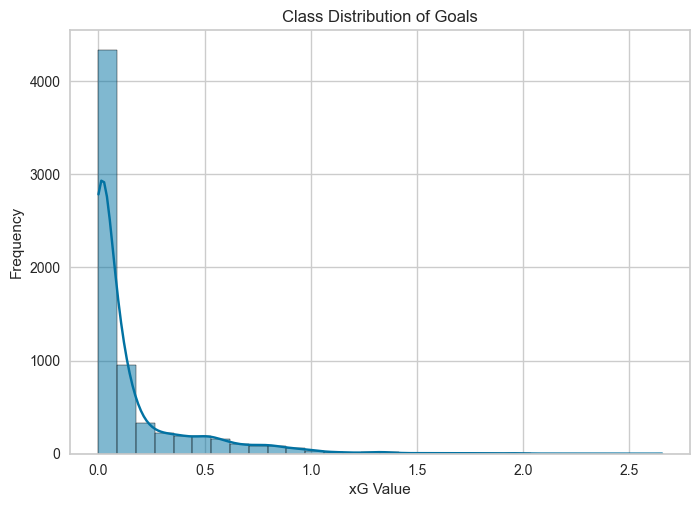

In [75]:
print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

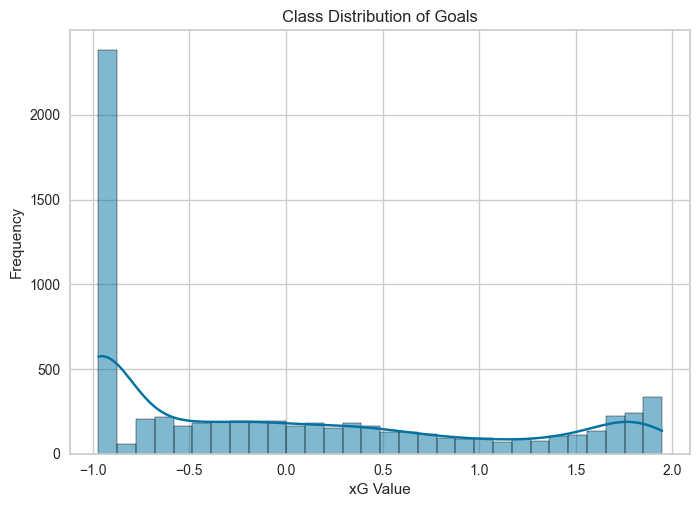

In [76]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(mid_xg_data[['xG']])

mid_xg_data['xG'] = pt.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [77]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE', n_select=1)
base_mid_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004429 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7447
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 81
[LightGBM] [Info] Start training from score -0.003713


,Description,Value
0,Session id,781
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6837, 147)"
4,Transformed data shape,"(6837, 30)"
5,Transformed train set shape,"(5469, 30)"
6,Transformed test set shape,"(1368, 30)"
7,Numeric features,145
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3663,0.2794,0.5282,0.7161,0.2593,2.6955,6.2840
et,Extra Trees Regressor,0.3703,0.2819,0.5307,0.7136,0.2597,2.6299,2.7060
gbr,Gradient Boosting Regressor,0.3719,0.2749,0.5240,0.7206,0.2567,2.4069,1.9360
lightgbm,Light Gradient Boosting Machine,0.3742,0.2830,0.5315,0.7123,0.2603,2.5244,1.0060
xgboost,Extreme Gradient Boosting,0.3966,0.3105,0.5568,0.6843,0.2671,3.4100,1.0730
ada,AdaBoost Regressor,0.4512,0.3224,0.5675,0.6722,0.2891,2.6688,1.1730
knn,K Neighbors Regressor,0.4619,0.3930,0.6266,0.6009,0.2929,2.8483,1.4930
huber,Huber Regressor,0.4623,0.4070,0.6377,0.5864,0.2895,1.8367,2.2550
lr,Linear Regression,0.4799,0.3818,0.6177,0.6123,0.3024,1.7046,4.0160
ridge,Ridge Regression,0.4800,0.3817,0.6176,0.6124,0.3024,1.7062,1.2370


RandomForestRegressor(n_jobs=-1, random_state=781)

In [78]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

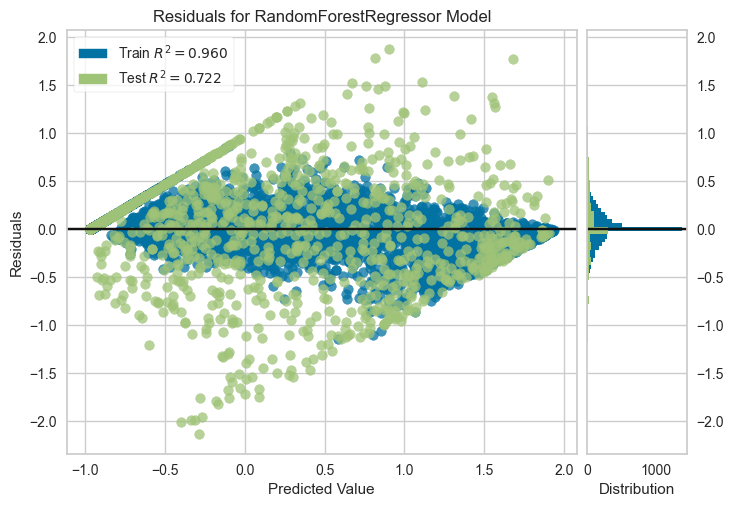

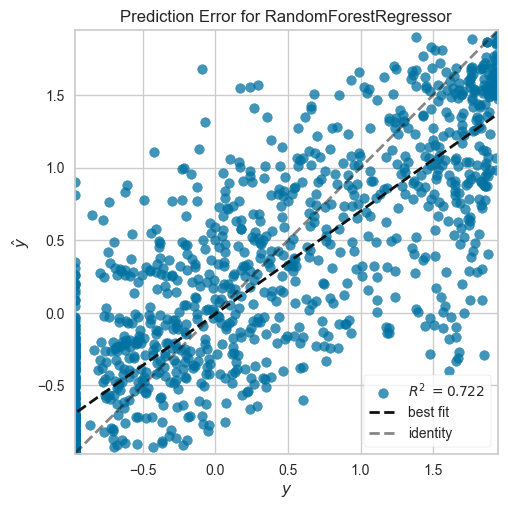

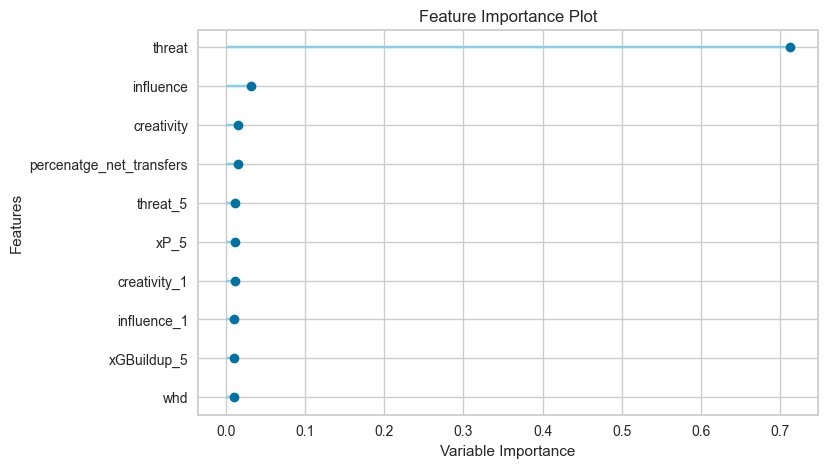

In [79]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Blended Model


In [80]:
blend_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xg_best = compare_models(n_select=3, sort='MAE')
print(mid_xg_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xg_blended = blend_models(mid_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7453
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 82
[LightGBM] [Info] Start training from score -0.003392


,Description,Value
0,Session id,1529
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6837, 147)"
4,Transformed data shape,"(6837, 30)"
5,Transformed train set shape,"(5469, 30)"
6,Transformed test set shape,"(1368, 30)"
7,Numeric features,145
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3652,0.2822,0.5309,0.7192,0.2598,2.4772,5.2900
et,Extra Trees Regressor,0.3691,0.2808,0.5295,0.7207,0.2585,2.4792,2.5830
gbr,Gradient Boosting Regressor,0.3730,0.2762,0.5252,0.7253,0.2571,2.3746,3.8100
lightgbm,Light Gradient Boosting Machine,0.3733,0.2826,0.5312,0.7189,0.2573,2.7019,1.2020
xgboost,Extreme Gradient Boosting,0.3984,0.3137,0.5599,0.6879,0.2670,2.5953,2.7180
knn,K Neighbors Regressor,0.4604,0.3968,0.6297,0.6055,0.2914,2.5300,0.6710
huber,Huber Regressor,0.4627,0.4125,0.6416,0.5904,0.2900,1.8864,0.8340
ada,AdaBoost Regressor,0.4672,0.3350,0.5785,0.6664,0.2948,2.7122,1.1110
dt,Decision Tree Regressor,0.4811,0.5579,0.7467,0.4445,0.3126,3.6023,0.7920
lr,Linear Regression,0.4825,0.3872,0.6218,0.6155,0.3029,1.7225,1.4120


[RandomForestRegressor(n_jobs=-1, random_state=1529), ExtraTreesRegressor(n_jobs=-1, random_state=1529), GradientBoostingRegressor(random_state=1529)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3762,0.2902,0.5387,0.7073,0.2589,1.9175
1,0.3833,0.2816,0.5306,0.7075,0.2579,3.9051
2,0.3703,0.2705,0.5201,0.7313,0.2486,1.2048
3,0.3384,0.2287,0.4783,0.7709,0.2529,2.3664
4,0.3452,0.2440,0.4940,0.7506,0.2566,1.9984
5,0.3670,0.2819,0.5309,0.7109,0.2627,1.5691
6,0.3552,0.2662,0.5160,0.7496,0.2536,1.4484
7,0.3591,0.2962,0.5443,0.7154,0.2489,1.9019
8,0.3888,0.2987,0.5466,0.7246,0.2695,6.2803


### Save Model


In [5]:
mid_xg_final_model = finalize_model(mid_xg_blended)
save_model(mid_xg_final_model, 'mid_xg_final_model')

NameError: name 'mid_xg_blended' is not defined

## For


xG
0.000000    283
0.761169      6
0.295594      2
0.080153      2
0.416487      2
           ... 
0.319068      1
1.631009      1
0.619680      1
0.177437      1
0.354086      1
Name: count, Length: 1243, dtype: int64


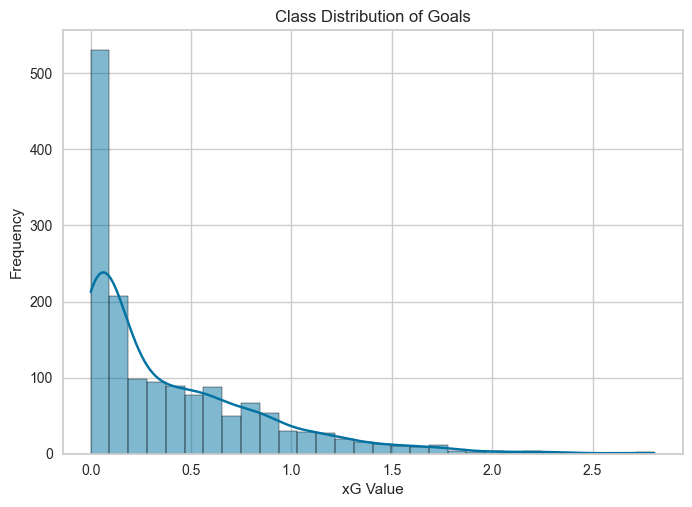

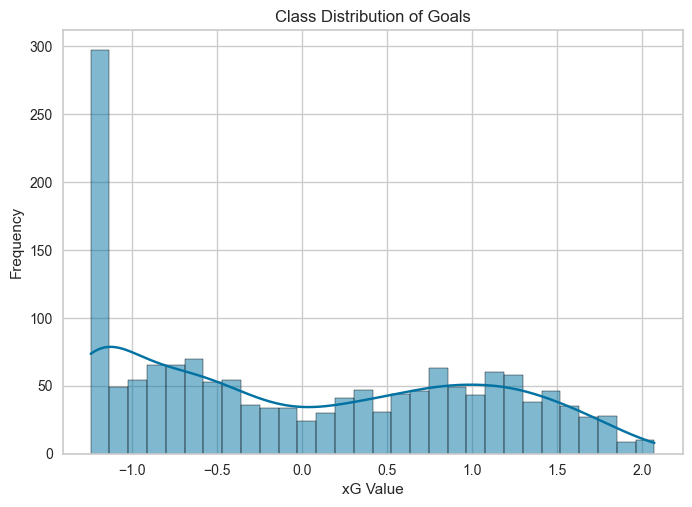

In [7]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(fwd_xg_data[['xG']])

fwd_xg_data['xG'] = pt.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6191
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 81
[LightGBM] [Info] Start training from score 0.009768


,Description,Value
0,Session id,805
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1540, 148)"
4,Transformed data shape,"(1540, 30)"
5,Transformed train set shape,"(1232, 30)"
6,Transformed test set shape,"(308, 30)"
7,Numeric features,146
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4137,0.2950,0.5384,0.6992,0.2636,1.1400,0.7230
rf,Random Forest Regressor,0.4155,0.3037,0.5463,0.6905,0.2652,1.1217,1.4940
et,Extra Trees Regressor,0.4216,0.3132,0.5548,0.6808,0.2700,1.0367,0.9710
lightgbm,Light Gradient Boosting Machine,0.4289,0.3176,0.5591,0.6760,0.2638,1.2255,0.5790
xgboost,Extreme Gradient Boosting,0.4471,0.3461,0.5838,0.6473,0.2720,1.2761,0.8540
lr,Linear Regression,0.4913,0.3660,0.5984,0.6261,0.2880,1.1424,1.9240
ridge,Ridge Regression,0.4917,0.3654,0.5979,0.6266,0.2879,1.1451,0.4280
huber,Huber Regressor,0.4917,0.3961,0.6227,0.5948,0.2790,1.1899,0.4910
br,Bayesian Ridge,0.4932,0.3673,0.5989,0.6246,0.2887,1.1208,0.4210
knn,K Neighbors Regressor,0.4960,0.4139,0.6421,0.5758,0.2798,1.1005,0.4180


GradientBoostingRegressor(random_state=805)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


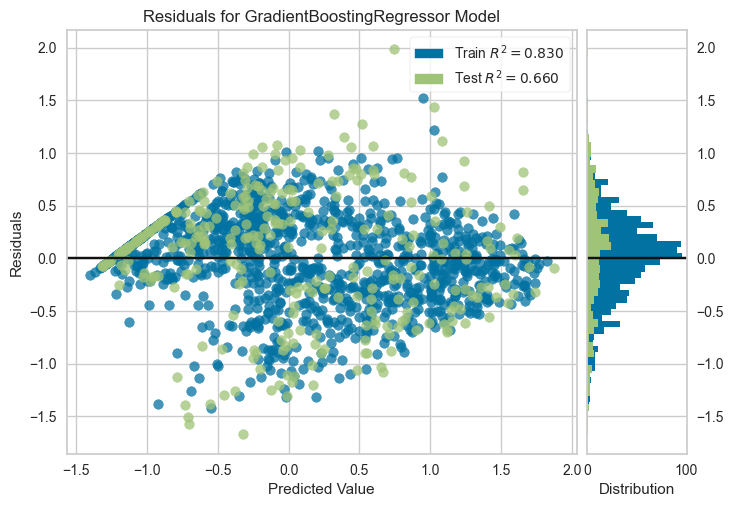

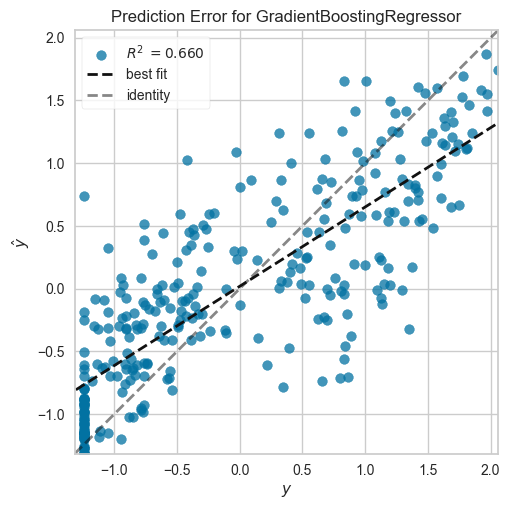

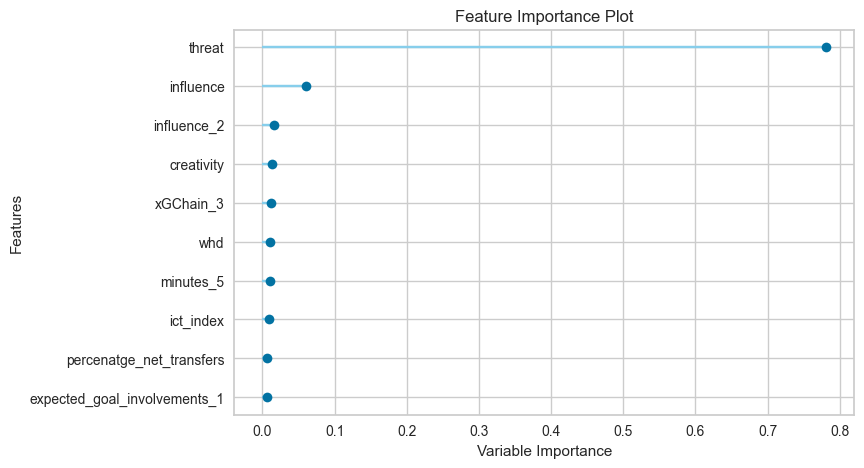

In [14]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Blended Model


In [10]:
blend_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xg_best = compare_models(n_select=3, sort='MAE')
print(fwd_xg_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xg_blended = blend_models(fwd_xg_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5809
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 80
[LightGBM] [Info] Start training from score -0.011973


,Description,Value
0,Session id,4188
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1540, 147)"
4,Transformed data shape,"(1540, 30)"
5,Transformed train set shape,"(1232, 30)"
6,Transformed test set shape,"(308, 30)"
7,Numeric features,145
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.4342,0.3269,0.5709,0.6687,0.2705,2.0990,1.5620
et,Extra Trees Regressor,0.4376,0.3253,0.5689,0.6702,0.2702,1.9816,1.0140
lightgbm,Light Gradient Boosting Machine,0.4380,0.3358,0.5783,0.6596,0.2688,2.4144,0.7870
gbr,Gradient Boosting Regressor,0.4404,0.3277,0.5712,0.6681,0.2661,1.9939,0.8210
xgboost,Extreme Gradient Boosting,0.4589,0.3622,0.6004,0.6329,0.2700,1.9554,0.6050
knn,K Neighbors Regressor,0.4778,0.3880,0.6202,0.6065,0.2807,2.3283,0.5010
huber,Huber Regressor,0.5012,0.4089,0.6389,0.5855,0.2837,1.5398,0.7540
lr,Linear Regression,0.5033,0.3817,0.6173,0.6132,0.2933,1.6317,2.0430
ridge,Ridge Regression,0.5035,0.3810,0.6167,0.6139,0.2935,1.6394,0.6810
br,Bayesian Ridge,0.5056,0.3831,0.6182,0.6119,0.2916,1.5720,0.6500


[RandomForestRegressor(n_jobs=-1, random_state=4188), ExtraTreesRegressor(n_jobs=-1, random_state=4188), LGBMRegressor(n_jobs=-1, random_state=4188)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4818,0.3830,0.6189,0.6410,0.2748,0.7177
1,0.3917,0.2654,0.5152,0.7300,0.2491,0.8333
2,0.4412,0.3536,0.5947,0.6512,0.2658,0.9631
3,0.4583,0.3451,0.5875,0.6516,0.2764,0.8085
4,0.3579,0.2701,0.5197,0.7204,0.2238,0.9440
5,0.4526,0.3288,0.5734,0.6855,0.2803,0.8781
6,0.4422,0.3289,0.5735,0.6656,0.2628,0.8476
7,0.4773,0.3582,0.5985,0.6022,0.3111,12.5080
8,0.3963,0.2950,0.5432,0.6798,0.2529,1.6345


### Save Model


In [15]:
fwd_xg_final_model = finalize_model(base_fwd_xg_best)
save_model(fwd_xg_final_model, 'fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [16]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4396
0.024878       2
0.064864       2
0.094357       2
0.074853       2
            ... 
0.018557       1
0.009202       1
0.939291       1
0.027244       1
0.065300       1
Name: count, Length: 2033, dtype: int64


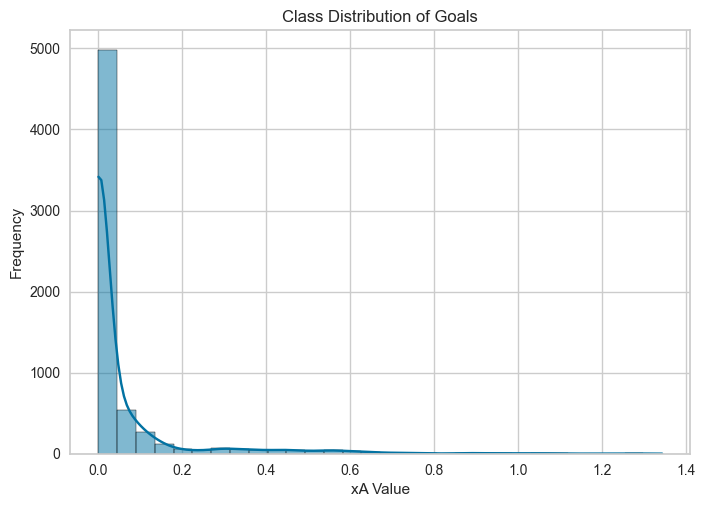

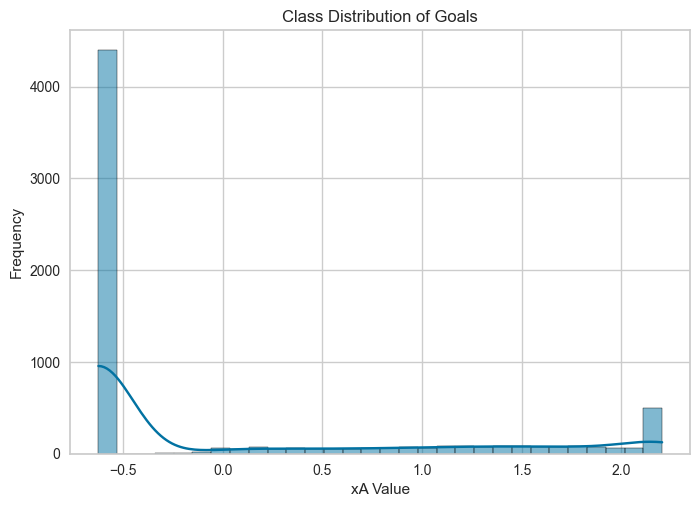

In [17]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xa_data[['xA']])

def_xa_data['xA'] = pt.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003011 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6107
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 78
[LightGBM] [Info] Start training from score 0.011893


,Description,Value
0,Session id,6382
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6455, 118)"
4,Transformed data shape,"(6455, 24)"
5,Transformed train set shape,"(5164, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,116
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2011,0.1817,0.4253,0.8214,0.1870,4.7899,2.4040
et,Extra Trees Regressor,0.2046,0.1801,0.4233,0.8229,0.1881,4.3136,2.1740
gbr,Gradient Boosting Regressor,0.2096,0.1812,0.4245,0.8219,0.1873,4.4238,2.4070
lightgbm,Light Gradient Boosting Machine,0.2135,0.1894,0.4341,0.8137,0.1952,4.3042,1.0530
ada,AdaBoost Regressor,0.2141,0.1902,0.4354,0.8131,0.1891,3.9079,1.3270
xgboost,Extreme Gradient Boosting,0.2304,0.2089,0.4558,0.7946,0.2012,4.1225,0.9930
knn,K Neighbors Regressor,0.2525,0.2565,0.5059,0.7474,0.2279,4.4050,1.3710
dt,Decision Tree Regressor,0.2626,0.3546,0.5941,0.6518,0.2510,5.3664,0.9690
huber,Huber Regressor,0.3404,0.3899,0.6232,0.6176,0.2837,1.3288,0.5860
ridge,Ridge Regression,0.4011,0.3696,0.6070,0.6374,0.2895,1.6290,0.7480


RandomForestRegressor(n_jobs=-1, random_state=6382)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


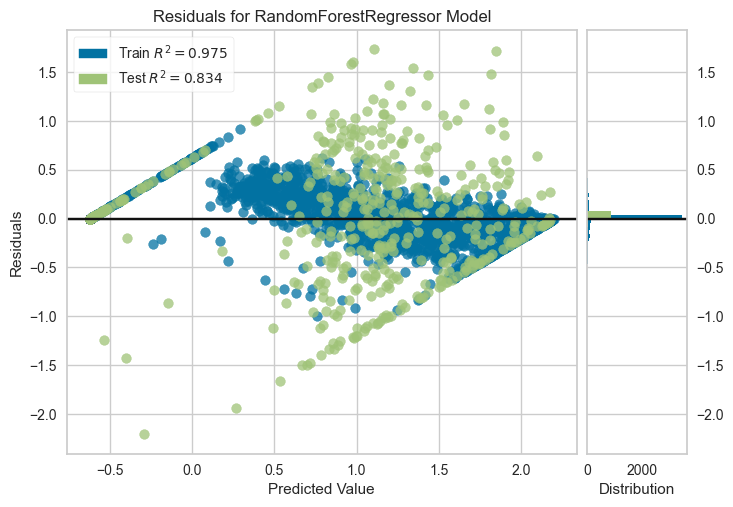

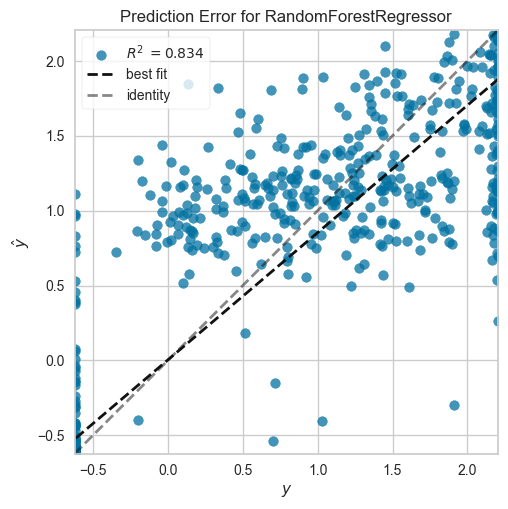

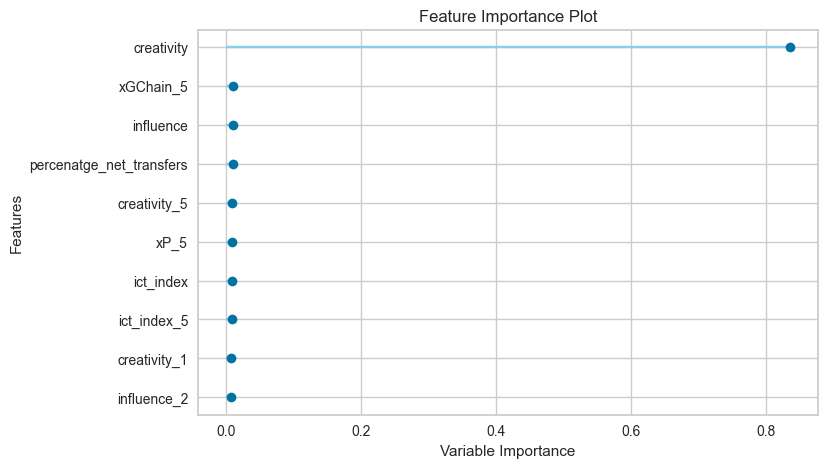

In [18]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Blended Model


In [20]:
blend_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xa_best = compare_models(n_select=3, sort='MAE')
print(def_xa_best)

print('Blended model')
# Ensemble (blend or stack)
def_xa_blended = blend_models(def_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6053
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 77
[LightGBM] [Info] Start training from score -0.014499


,Description,Value
0,Session id,4751
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6455, 118)"
4,Transformed data shape,"(6455, 24)"
5,Transformed train set shape,"(5164, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,116
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1922,0.1700,0.4107,0.8260,0.1832,4.1192,3.8440
et,Extra Trees Regressor,0.1955,0.1681,0.4084,0.8279,0.1834,4.3073,1.8640
gbr,Gradient Boosting Regressor,0.2010,0.1686,0.4087,0.8275,0.1821,3.9114,2.0520
lightgbm,Light Gradient Boosting Machine,0.2055,0.1782,0.4207,0.8176,0.1912,4.2654,1.3770
ada,AdaBoost Regressor,0.2076,0.1752,0.4170,0.8211,0.1849,3.7338,1.4540
xgboost,Extreme Gradient Boosting,0.2259,0.2016,0.4471,0.7936,0.2002,4.6325,1.4800
knn,K Neighbors Regressor,0.2453,0.2477,0.4965,0.7469,0.2300,3.6863,0.7450
dt,Decision Tree Regressor,0.2527,0.3299,0.5736,0.6629,0.2491,1.5476,1.3920
huber,Huber Regressor,0.3288,0.3857,0.6181,0.6069,0.2769,1.2665,1.0020
ridge,Ridge Regression,0.3926,0.3648,0.6022,0.6280,0.2865,1.5601,0.7220


[RandomForestRegressor(n_jobs=-1, random_state=4751), ExtraTreesRegressor(n_jobs=-1, random_state=4751), GradientBoostingRegressor(random_state=4751)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1701,0.1263,0.3553,0.8706,0.1606,0.4984
1,0.2244,0.1825,0.4272,0.8361,0.1985,1.1155
2,0.2312,0.2308,0.4804,0.7575,0.2024,1.0448
3,0.2087,0.1872,0.4326,0.8123,0.1962,1.0031
4,0.1800,0.1446,0.3803,0.8486,0.1724,0.6699
5,0.1807,0.1636,0.4044,0.8168,0.1858,5.4372
6,0.2102,0.1940,0.4405,0.7948,0.1853,29.6574
7,0.1917,0.1566,0.3958,0.8333,0.1808,0.8353
8,0.1729,0.1369,0.3700,0.8613,0.1685,0.3435


### Save Model


In [22]:
def_xa_final_model = finalize_model(def_xa_blended)
save_model(def_xa_final_model, 'def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## Mid


xA
0.000000    2754
0.206606       2
0.066186       2
0.476796       2
0.043460       2
            ... 
0.016043       1
0.176516       1
0.072403       1
0.181037       1
1.060860       1
Name: count, Length: 4038, dtype: int64


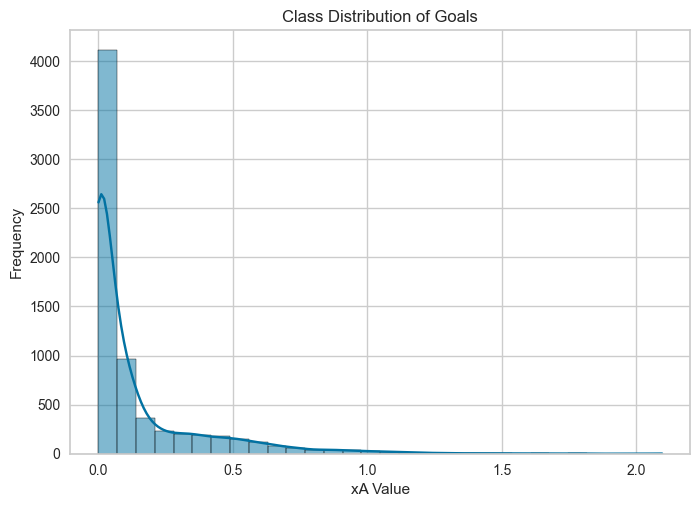

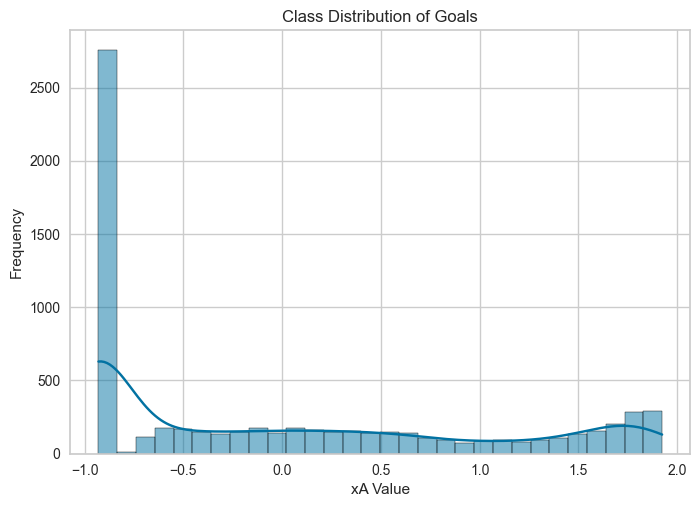

In [23]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(mid_xa_data[['xA']])

mid_xa_data['xA'] = pt.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7345
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 76
[LightGBM] [Info] Start training from score -0.001862


,Description,Value
0,Session id,2561
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6837, 118)"
4,Transformed data shape,"(6837, 24)"
5,Transformed train set shape,"(5469, 24)"
6,Transformed test set shape,"(1368, 24)"
7,Numeric features,116
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3531,0.3046,0.5517,0.6929,0.2679,1.9629,4.4930
et,Extra Trees Regressor,0.3579,0.3047,0.5519,0.6926,0.2695,1.6619,2.1230
gbr,Gradient Boosting Regressor,0.3623,0.2983,0.5460,0.6991,0.2766,1.8495,1.7390
lightgbm,Light Gradient Boosting Machine,0.3659,0.3099,0.5566,0.6875,0.2706,2.4488,0.7880
ada,AdaBoost Regressor,0.3850,0.3258,0.5706,0.6713,0.2501,2.2589,0.9590
xgboost,Extreme Gradient Boosting,0.3999,0.3468,0.5887,0.6502,0.2739,2.1211,1.0070
knn,K Neighbors Regressor,0.4387,0.4139,0.6431,0.5828,0.2965,1.9316,0.6840
huber,Huber Regressor,0.4391,0.4300,0.6552,0.5671,0.2992,1.7248,0.6770
dt,Decision Tree Regressor,0.4677,0.6023,0.7756,0.3917,0.3121,3.8488,0.7050
ridge,Ridge Regression,0.4728,0.4048,0.6358,0.5923,0.3142,1.4057,0.6330


RandomForestRegressor(n_jobs=-1, random_state=2561)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


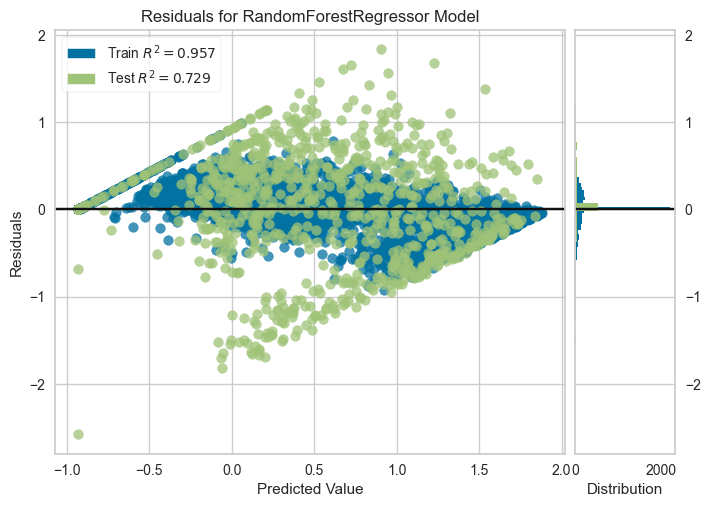

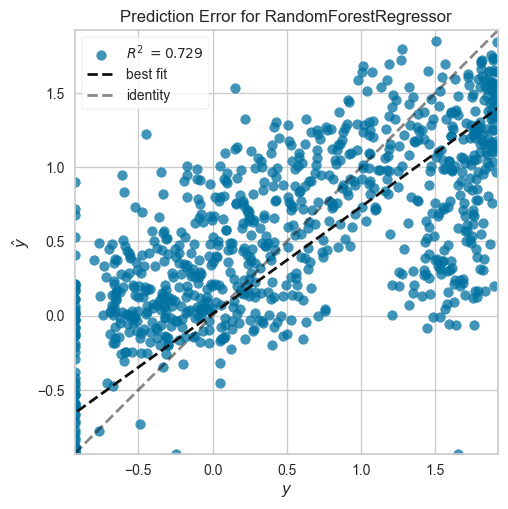

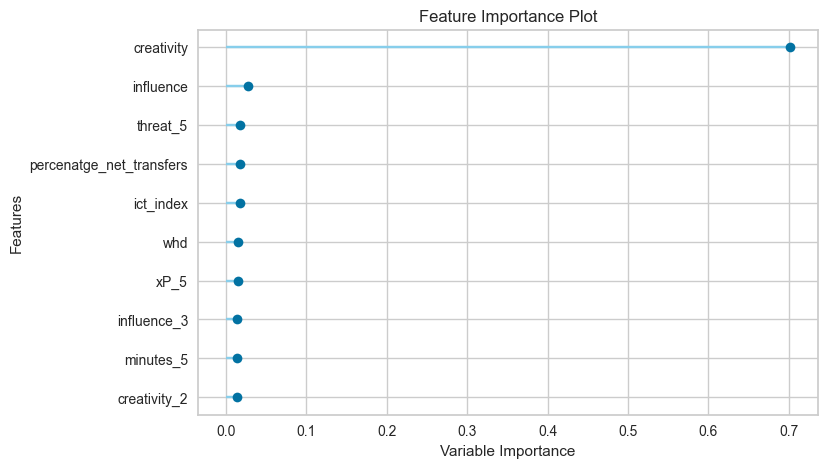

In [24]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Blended model


In [25]:
blend_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xa_best = compare_models(n_select=3, sort='MAE')
print(mid_xa_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xa_blended = blend_models(mid_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7536
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 78
[LightGBM] [Info] Start training from score -0.002743


,Description,Value
0,Session id,7265
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6837, 118)"
4,Transformed data shape,"(6837, 24)"
5,Transformed train set shape,"(5469, 24)"
6,Transformed test set shape,"(1368, 24)"
7,Numeric features,116
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3505,0.2998,0.5468,0.6965,0.2645,1.4395,4.4560
et,Extra Trees Regressor,0.3545,0.2997,0.5468,0.6966,0.2651,1.4408,2.1180
gbr,Gradient Boosting Regressor,0.3596,0.2959,0.5433,0.7003,0.2754,1.4362,1.8190
lightgbm,Light Gradient Boosting Machine,0.3642,0.3083,0.5547,0.6878,0.2700,1.6116,1.0180
ada,AdaBoost Regressor,0.3870,0.3234,0.5681,0.6724,0.2453,1.8179,0.8370
xgboost,Extreme Gradient Boosting,0.3880,0.3312,0.5752,0.6646,0.2705,1.6231,1.1050
huber,Huber Regressor,0.4322,0.4224,0.6493,0.5729,0.2940,1.3760,0.7680
knn,K Neighbors Regressor,0.4331,0.4017,0.6335,0.5931,0.2892,1.9033,0.6410
ridge,Ridge Regression,0.4671,0.3990,0.6312,0.5964,0.3115,1.2994,0.8290
lr,Linear Regression,0.4671,0.3990,0.6312,0.5964,0.3115,1.2978,0.5980


[RandomForestRegressor(n_jobs=-1, random_state=7265), ExtraTreesRegressor(n_jobs=-1, random_state=7265), GradientBoostingRegressor(random_state=7265)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3533,0.2879,0.5366,0.7040,0.2526,0.8312
1,0.3885,0.3524,0.5936,0.6590,0.3001,2.0382
2,0.3676,0.3192,0.5650,0.6759,0.2721,1.3388
3,0.3212,0.2462,0.4962,0.7480,0.2498,1.1563
4,0.3430,0.2861,0.5349,0.6981,0.2793,2.3506
5,0.3343,0.2649,0.5147,0.7427,0.2508,1.1408
6,0.3246,0.2661,0.5158,0.7433,0.2614,0.9505
7,0.3453,0.2880,0.5367,0.7133,0.2662,1.3463
8,0.3761,0.3230,0.5684,0.6606,0.2662,1.0852


### Save Model


In [26]:
mid_xa_final_model = finalize_model(mid_xa_blended)
save_model(mid_xa_final_model, 'mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## For


xA
0.000000    744
0.619269      2
0.048648      2
0.505651      2
0.496048      2
           ... 
0.159140      1
0.065082      1
0.073396      1
0.302196      1
0.092675      1
Name: count, Length: 792, dtype: int64


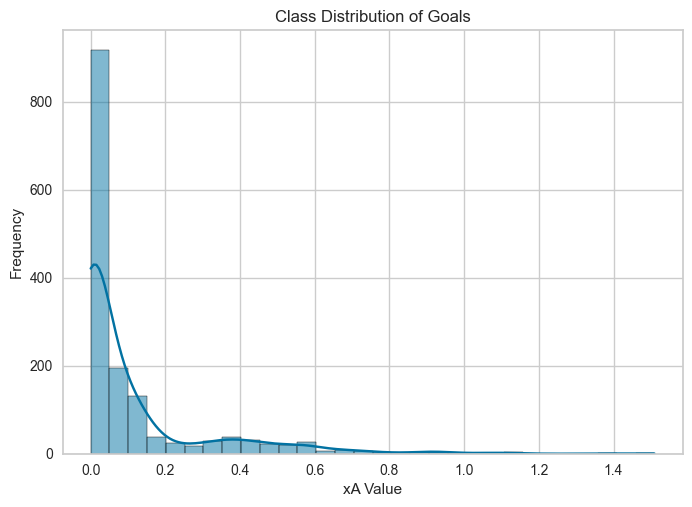

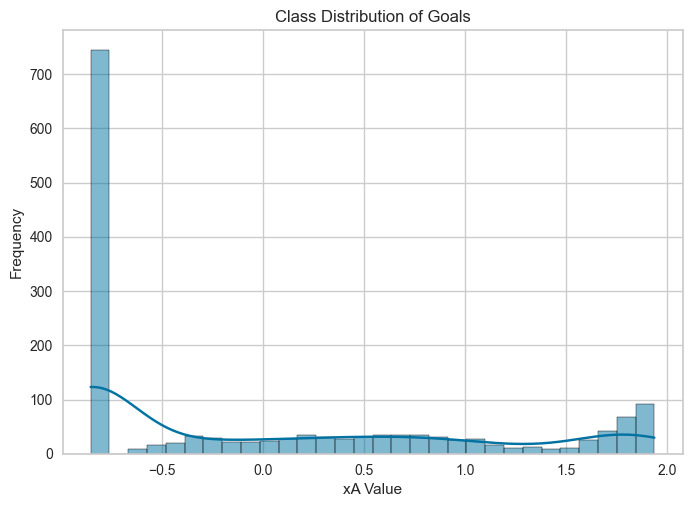

In [27]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(fwd_xa_data[['xA']])

fwd_xa_data['xA'] = pt.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6978
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 81
[LightGBM] [Info] Start training from score -0.000866
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,5288
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1540, 118)"
4,Transformed data shape,"(1540, 24)"
5,Transformed train set shape,"(1232, 24)"
6,Transformed test set shape,"(308, 24)"
7,Numeric features,116
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3153,0.2755,0.5223,0.7223,0.2360,1.1136,1.2250
et,Extra Trees Regressor,0.3182,0.2674,0.5145,0.7307,0.2332,1.1098,0.9320
gbr,Gradient Boosting Regressor,0.3324,0.2759,0.5227,0.7214,0.2360,1.0800,0.8870
lightgbm,Light Gradient Boosting Machine,0.3453,0.2953,0.5405,0.7024,0.2460,1.2120,0.8610
xgboost,Extreme Gradient Boosting,0.3591,0.3352,0.5759,0.6622,0.2550,1.3272,0.6850
huber,Huber Regressor,0.4054,0.3845,0.6193,0.6145,0.2988,0.8147,0.6350
dt,Decision Tree Regressor,0.4075,0.5096,0.7093,0.4866,0.3013,1.4213,0.5060
br,Bayesian Ridge,0.4369,0.3757,0.6122,0.6227,0.3057,0.8649,0.4370
omp,Orthogonal Matching Pursuit,0.4392,0.3747,0.6114,0.6241,0.3098,0.8638,0.5560
ridge,Ridge Regression,0.4399,0.3792,0.6151,0.6192,0.3054,0.9061,0.4670


RandomForestRegressor(n_jobs=-1, random_state=5288)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


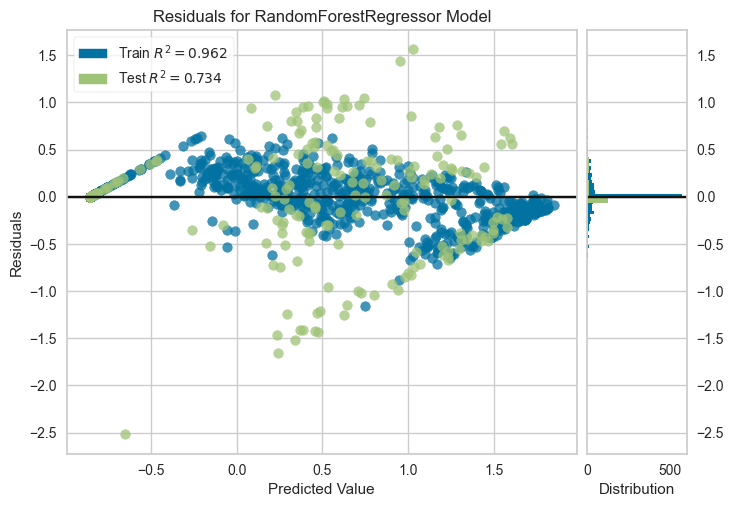

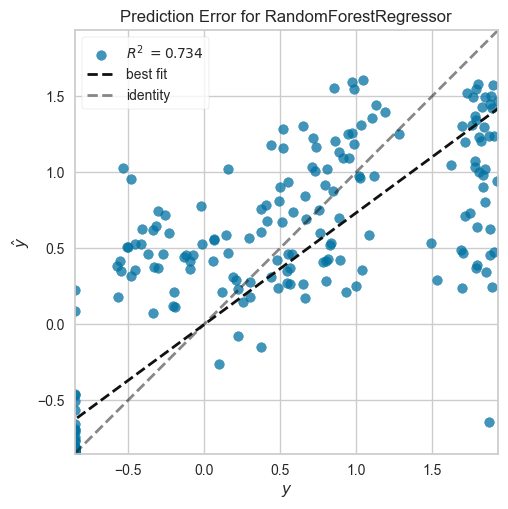

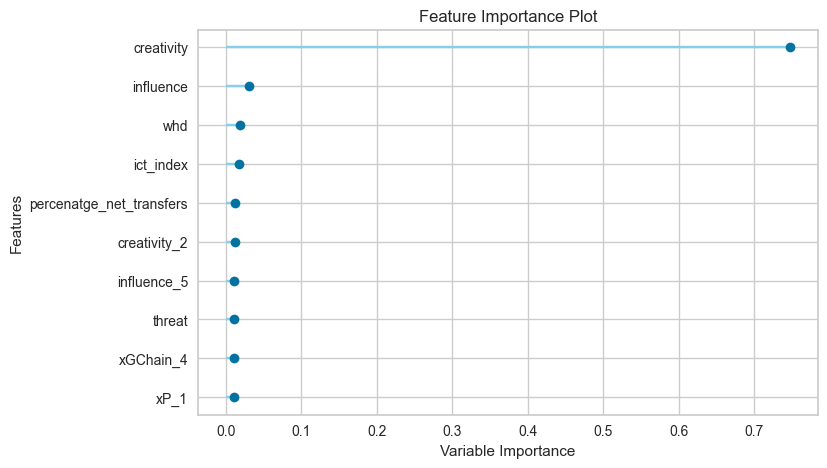

In [28]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Blended model


In [29]:
blend_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xa_best = compare_models(n_select=3, sort='MAE')
print(fwd_xa_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xa_blended = blend_models(fwd_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7167
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 82
[LightGBM] [Info] Start training from score 0.009568


,Description,Value
0,Session id,1695
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1540, 118)"
4,Transformed data shape,"(1540, 24)"
5,Transformed train set shape,"(1232, 24)"
6,Transformed test set shape,"(308, 24)"
7,Numeric features,116
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3193,0.2800,0.5281,0.7216,0.2378,1.0429,1.4670
et,Extra Trees Regressor,0.3211,0.2680,0.5165,0.7337,0.2323,1.0364,1.1600
gbr,Gradient Boosting Regressor,0.3317,0.2728,0.5215,0.7290,0.2305,0.9989,0.9420
lightgbm,Light Gradient Boosting Machine,0.3489,0.2991,0.5457,0.7025,0.2506,1.1838,0.7750
xgboost,Extreme Gradient Boosting,0.3617,0.3299,0.5734,0.6722,0.2652,1.1950,0.7660
huber,Huber Regressor,0.4148,0.4025,0.6330,0.6023,0.3030,0.7958,0.5260
dt,Decision Tree Regressor,0.4273,0.5569,0.7432,0.4471,0.3077,1.4331,0.4240
omp,Orthogonal Matching Pursuit,0.4436,0.3809,0.6161,0.6242,0.3105,0.8309,0.4730
br,Bayesian Ridge,0.4437,0.3812,0.6162,0.6237,0.3082,0.8430,0.6050
ridge,Ridge Regression,0.4456,0.3843,0.6186,0.6203,0.3077,0.8568,1.0000


[RandomForestRegressor(n_jobs=-1, random_state=1695), ExtraTreesRegressor(n_jobs=-1, random_state=1695), GradientBoostingRegressor(random_state=1695)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2899,0.2511,0.5011,0.7354,0.2388,0.5744
1,0.3213,0.2396,0.4895,0.7752,0.2235,0.5427
2,0.2952,0.2607,0.5106,0.7772,0.1964,0.4014
3,0.3102,0.2416,0.4915,0.7601,0.2216,0.7666
4,0.3378,0.2800,0.5292,0.6929,0.2273,0.8688
5,0.3645,0.3361,0.5797,0.6626,0.2403,1.2865
6,0.2907,0.2292,0.4788,0.8026,0.2204,0.5656
7,0.2953,0.2279,0.4774,0.7517,0.2238,1.1881
8,0.3531,0.2908,0.5393,0.7154,0.2478,1.3695


### Save Model


In [30]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, 'fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2.0     347
3.0     296
1.0     250
4.0     229
5.0     151
0.0     121
6.0      85
7.0      52
8.0      21
9.0      15
10.0      4
11.0      2
12.0      1
13.0      1
Name: count, dtype: int64


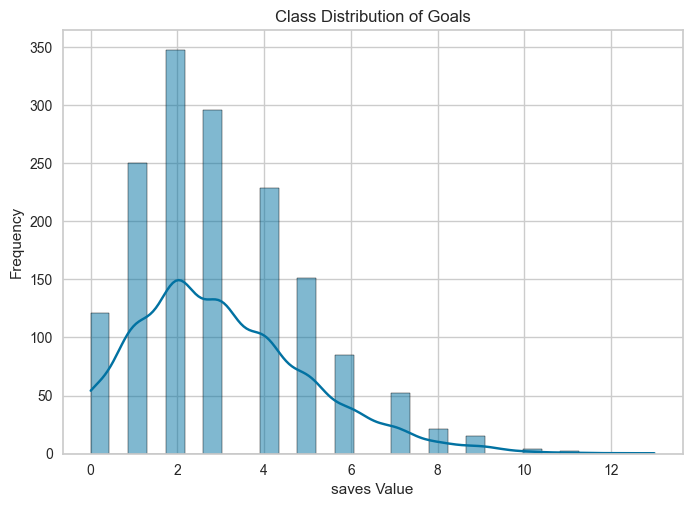

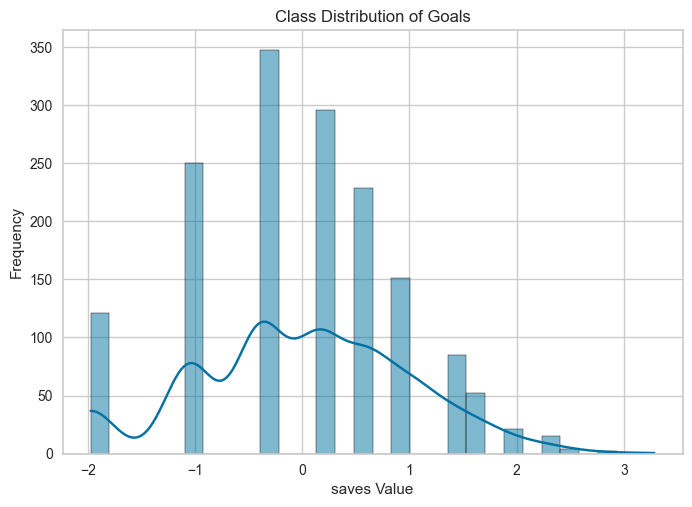

In [31]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(g_saves_data[['saves']])

g_saves_data['saves'] = pt.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2976
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 65
[LightGBM] [Info] Start training from score -0.004515


,Description,Value
0,Session id,6594
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(1575, 24)"
5,Transformed train set shape,"(1260, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2675,0.1375,0.3683,0.8607,0.1836,0.6289,0.8320
rf,Random Forest Regressor,0.2693,0.1418,0.3741,0.8557,0.1848,0.6336,1.1050
et,Extra Trees Regressor,0.2732,0.1408,0.3729,0.8567,0.1854,0.6444,0.8350
lightgbm,Light Gradient Boosting Machine,0.2851,0.1483,0.3836,0.8492,0.1921,0.6797,0.7690
xgboost,Extreme Gradient Boosting,0.2973,0.1661,0.4050,0.8312,0.1995,0.6940,0.5800
omp,Orthogonal Matching Pursuit,0.3113,0.1792,0.4202,0.8180,0.1981,0.6905,0.3000
br,Bayesian Ridge,0.3118,0.1794,0.4204,0.8178,0.1990,0.6928,0.3240
ridge,Ridge Regression,0.3125,0.1793,0.4204,0.8179,0.2006,0.6914,0.3000
lr,Linear Regression,0.3129,0.1796,0.4207,0.8177,0.2010,0.6921,5.5120
dt,Decision Tree Regressor,0.3135,0.2541,0.4998,0.7404,0.2340,0.7809,0.5900


GradientBoostingRegressor(random_state=6594)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


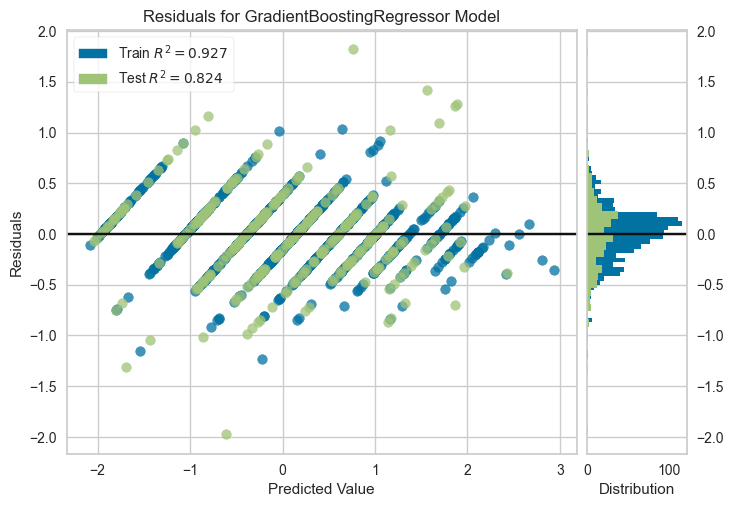

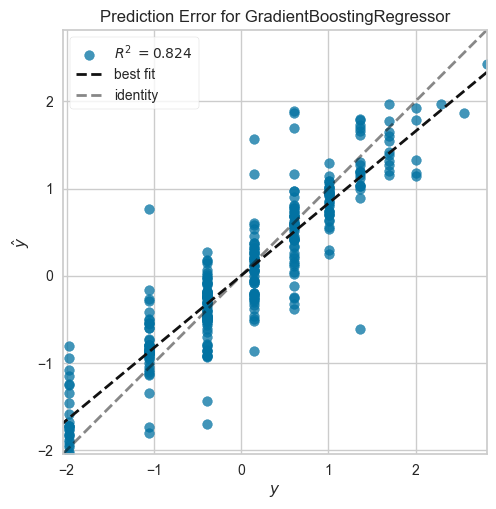

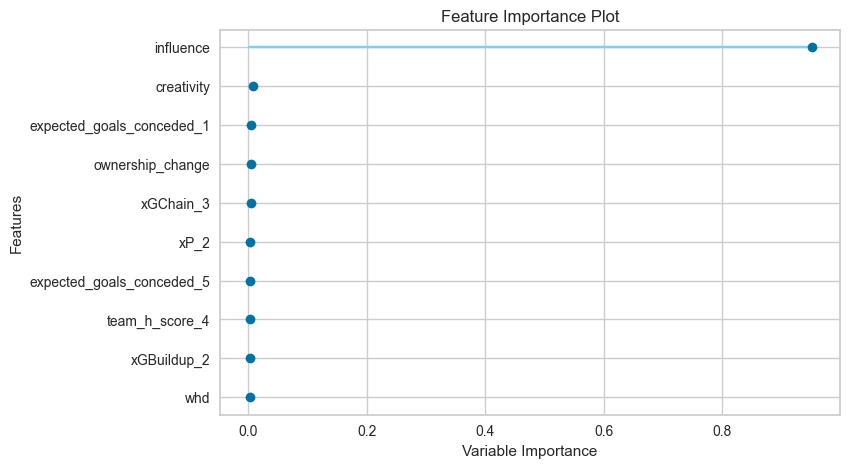

In [33]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Blended Model


In [34]:
blend_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_saves_best = compare_models(n_select=3, sort='MAE')
print(g_saves_best)

print('Blended model')
# Ensemble (blend or stack)
g_saves_blended = blend_models(g_saves_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 64
[LightGBM] [Info] Start training from score 0.025373


,Description,Value
0,Session id,2419
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(1575, 24)"
5,Transformed train set shape,"(1260, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2716,0.1369,0.3686,0.8620,0.1866,0.6564,0.5500
rf,Random Forest Regressor,0.2808,0.1483,0.3829,0.8507,0.1938,0.6715,0.8310
et,Extra Trees Regressor,0.2861,0.1472,0.3819,0.8518,0.1959,0.6874,0.7080
lightgbm,Light Gradient Boosting Machine,0.2918,0.1576,0.3947,0.8417,0.1991,0.7039,0.3920
xgboost,Extreme Gradient Boosting,0.3027,0.1751,0.4155,0.8234,0.2047,0.7201,0.4960
omp,Orthogonal Matching Pursuit,0.3102,0.1779,0.4203,0.8213,0.2010,0.7008,0.3290
br,Bayesian Ridge,0.3120,0.1790,0.4216,0.8203,0.2021,0.7040,0.2480
en,Elastic Net,0.3130,0.1790,0.4217,0.8201,0.2035,0.6888,0.2520
ridge,Ridge Regression,0.3134,0.1797,0.4223,0.8196,0.2031,0.7063,0.2560
lr,Linear Regression,0.3138,0.1799,0.4226,0.8193,0.2032,0.7069,0.3580


[GradientBoostingRegressor(random_state=2419), RandomForestRegressor(n_jobs=-1, random_state=2419), ExtraTreesRegressor(n_jobs=-1, random_state=2419)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2796,0.1380,0.3714,0.8708,0.2113,0.6848
1,0.2603,0.1149,0.3390,0.8858,0.1729,0.5257
2,0.2962,0.1565,0.3956,0.8563,0.1834,0.5551
3,0.2736,0.1239,0.3520,0.8522,0.1921,0.7931
4,0.2933,0.1544,0.3929,0.8159,0.1913,0.6498
5,0.2490,0.1162,0.3408,0.8642,0.1745,0.6513
6,0.2640,0.1472,0.3837,0.8612,0.1878,0.6221
7,0.2834,0.1369,0.3700,0.8839,0.1867,0.7201
8,0.3034,0.2086,0.4567,0.8078,0.2098,0.8406


### Save Model


In [35]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, 'g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [36]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.52    13
1.12    13
        ..
4.04     1
3.16     1
0.12     1
0.08     1
3.43     1
Name: count, Length: 342, dtype: int64


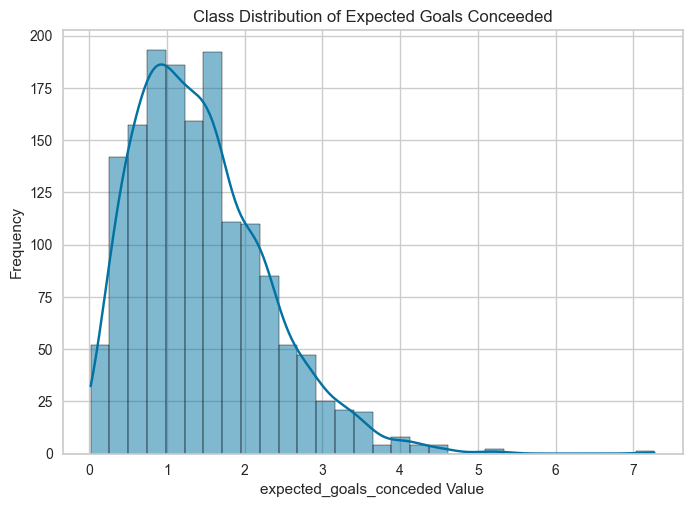

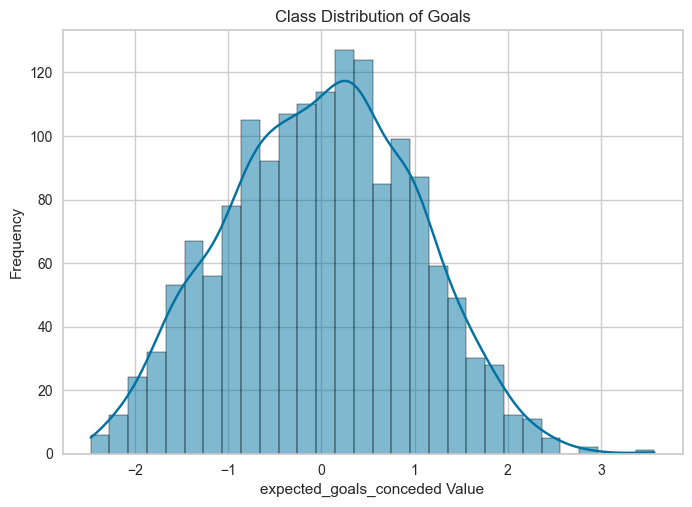

In [ ]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(g_xgc_data[['expected_goals_conceded']])

g_xgc_data['expected_goals_conceded'] = pt.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3016
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 68
[LightGBM] [Info] Start training from score 0.001686


,Description,Value
0,Session id,8451
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1575, 108)"
4,Transformed data shape,"(1575, 22)"
5,Transformed train set shape,"(1260, 22)"
6,Transformed test set shape,"(315, 22)"
7,Numeric features,106
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.7127,0.7743,0.8789,0.2306,0.4111,2.0286,0.9570
et,Extra Trees Regressor,0.7140,0.7766,0.8801,0.2269,0.4061,1.8451,1.5030
rf,Random Forest Regressor,0.7174,0.7774,0.8809,0.2264,0.4124,2.0289,2.0210
ridge,Ridge Regression,0.7204,0.7726,0.8783,0.2321,0.4029,1.9105,0.8080
lr,Linear Regression,0.7208,0.7736,0.8788,0.2312,0.4026,1.9255,3.6910
br,Bayesian Ridge,0.7223,0.7717,0.8779,0.2330,0.4094,1.8838,0.5450
ada,AdaBoost Regressor,0.7226,0.7797,0.8825,0.2255,0.4469,1.7087,0.7520
lightgbm,Light Gradient Boosting Machine,0.7353,0.8384,0.9146,0.1661,0.4037,2.2578,1.1040
omp,Orthogonal Matching Pursuit,0.7362,0.8029,0.8957,0.2020,0.4230,1.9136,0.7000
en,Elastic Net,0.7364,0.8041,0.8964,0.2010,0.4312,1.8243,0.6670


GradientBoostingRegressor(random_state=8451)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


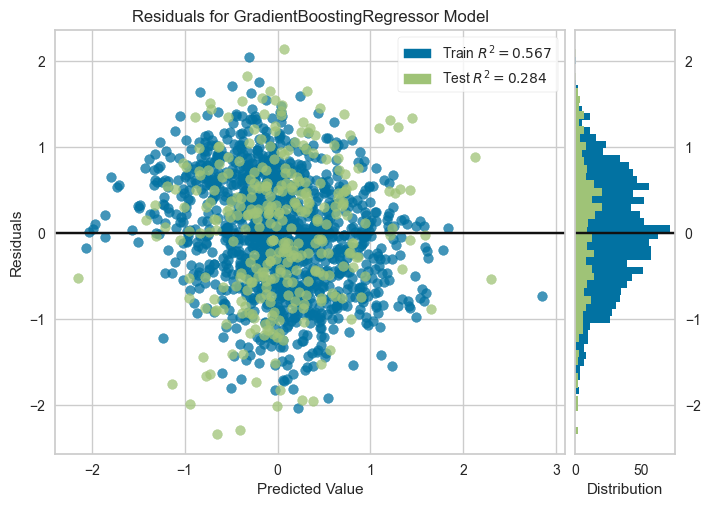

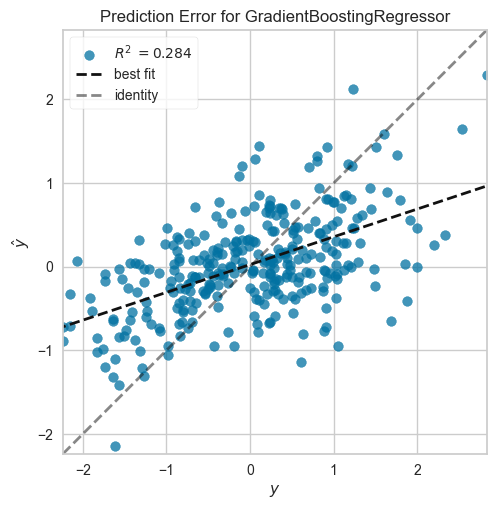

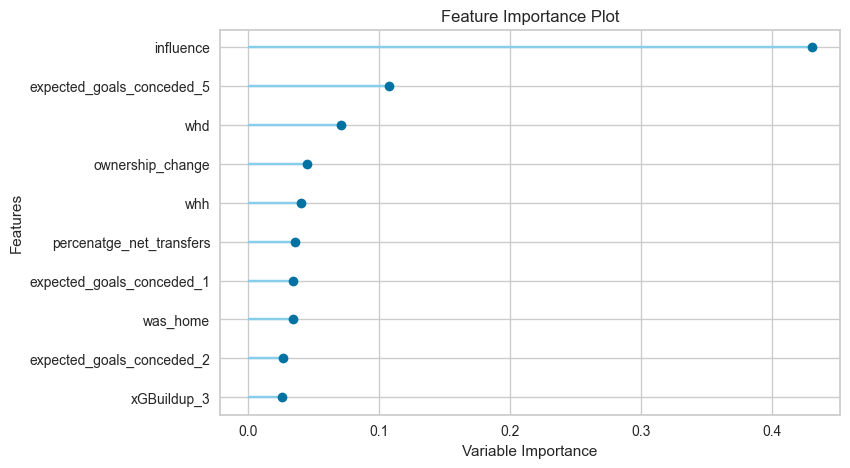

In [38]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [39]:
blend_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_xgc_best = compare_models(n_select=3, sort='MAE')
print(g_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
g_xgc_blended = blend_models(g_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.134235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3004
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 63
[LightGBM] [Info] Start training from score -0.003757


,Description,Value
0,Session id,4947
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1575, 108)"
4,Transformed data shape,"(1575, 22)"
5,Transformed train set shape,"(1260, 22)"
6,Transformed test set shape,"(315, 22)"
7,Numeric features,106
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.6954,0.7374,0.8567,0.2464,0.4050,2.0641,1.5520
et,Extra Trees Regressor,0.7000,0.7469,0.8616,0.2369,0.4037,2.0792,1.1900
lr,Linear Regression,0.7048,0.7473,0.8617,0.2365,0.4019,2.0998,0.5490
gbr,Gradient Boosting Regressor,0.7048,0.7569,0.8671,0.2263,0.4130,2.0574,0.7460
ridge,Ridge Regression,0.7052,0.7467,0.8614,0.2371,0.4018,2.1024,0.2460
br,Bayesian Ridge,0.7082,0.7470,0.8618,0.2365,0.4069,2.0896,0.4100
lightgbm,Light Gradient Boosting Machine,0.7235,0.8208,0.9043,0.1612,0.3938,2.1318,1.2480
ada,AdaBoost Regressor,0.7251,0.7813,0.8828,0.2016,0.4499,1.8294,0.9750
omp,Orthogonal Matching Pursuit,0.7283,0.7844,0.8840,0.1984,0.4210,2.1144,0.5520
en,Elastic Net,0.7289,0.7856,0.8848,0.1972,0.4293,2.0065,0.2730


[RandomForestRegressor(n_jobs=-1, random_state=4947), ExtraTreesRegressor(n_jobs=-1, random_state=4947), LinearRegression(n_jobs=-1)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7398,0.8172,0.9040,0.1468,0.4258,1.9555
1,0.6520,0.6453,0.8033,0.3368,0.3834,1.5852
2,0.7424,0.8229,0.9072,0.1325,0.4241,2.4686
3,0.7034,0.7378,0.8589,0.2030,0.3985,1.5488
4,0.6105,0.6126,0.7827,0.3363,0.3730,3.3369
5,0.6718,0.6937,0.8329,0.3630,0.4034,1.7814
6,0.7550,0.7915,0.8897,0.2373,0.4068,1.3013
7,0.6915,0.6995,0.8363,0.2719,0.4099,2.8717
8,0.5924,0.5224,0.7228,0.4505,0.3851,1.6449


### Save Model


In [57]:
g_xgc_final_model = finalize_model(g_xgc_blended)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                  TransformerWrapper(exclude=[],
                                     transformer=SelectFromModel(estimator=LGBMRegressor()

## Def


expected_goals_conceded
0.00    76
0.83    75
1.48    56
1.03    55
1.08    48
        ..
4.67     1
4.78     1
3.37     1
5.32     1
3.07     1
Name: count, Length: 383, dtype: int64


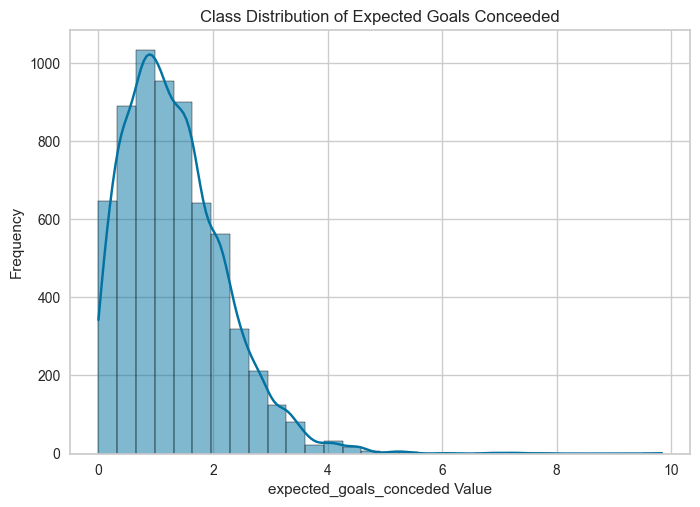

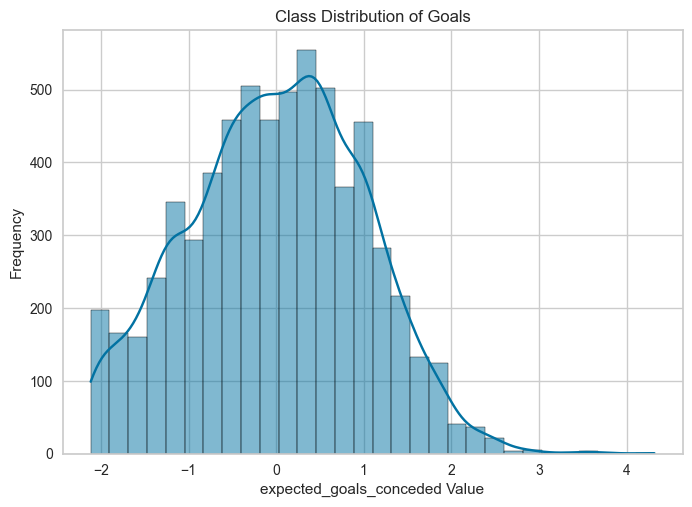

In [42]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xgc_data[['expected_goals_conceded']])

def_xgc_data['expected_goals_conceded'] = pt.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094623 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6412
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 70
[LightGBM] [Info] Start training from score -0.012549


,Description,Value
0,Session id,6761
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6455, 108)"
4,Transformed data shape,"(6455, 22)"
5,Transformed train set shape,"(5164, 22)"
6,Transformed test set shape,"(1291, 22)"
7,Numeric features,106
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6388,0.6475,0.8028,0.3435,0.3872,1.5280,2.1810
lightgbm,Light Gradient Boosting Machine,0.6629,0.6864,0.8280,0.3046,0.3909,1.6320,0.6790
xgboost,Extreme Gradient Boosting,0.6675,0.7138,0.8442,0.2765,0.3800,1.8270,0.8970
rf,Random Forest Regressor,0.6687,0.6996,0.8356,0.2911,0.4033,1.4828,4.5090
gbr,Gradient Boosting Regressor,0.6947,0.7402,0.8601,0.2500,0.4210,1.5243,1.3700
ada,AdaBoost Regressor,0.7509,0.8377,0.9148,0.1523,0.4770,1.3843,0.8420
lr,Linear Regression,0.7614,0.8697,0.9323,0.1194,0.4513,1.6128,1.0670
ridge,Ridge Regression,0.7615,0.8699,0.9324,0.1192,0.4515,1.6132,0.4720
br,Bayesian Ridge,0.7626,0.8712,0.9331,0.1179,0.4552,1.5965,0.4660
en,Elastic Net,0.7973,0.9440,0.9713,0.0449,0.5251,1.2516,0.6070


ExtraTreesRegressor(n_jobs=-1, random_state=6761)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


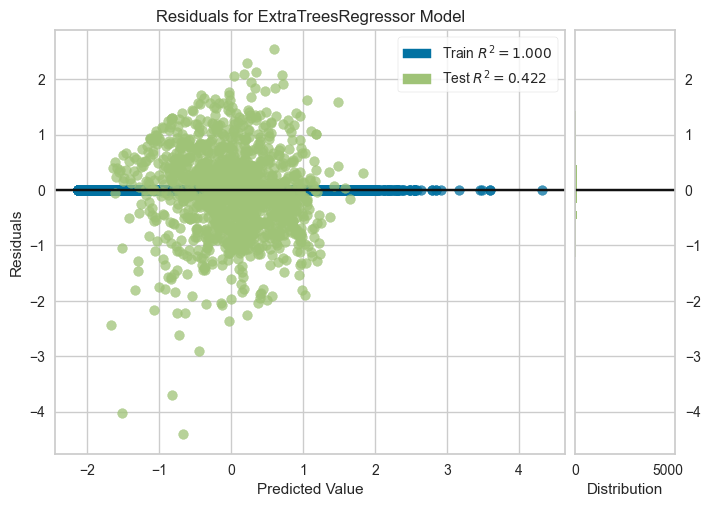

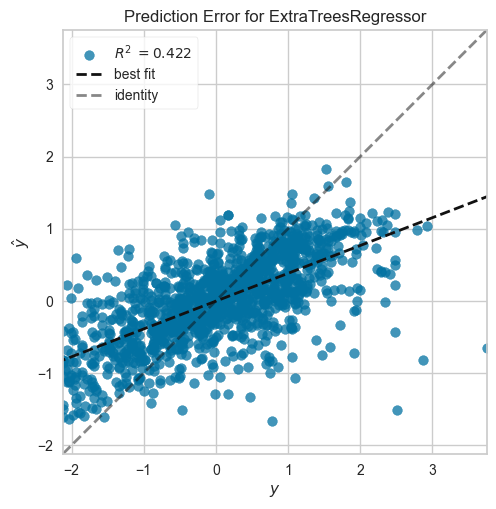

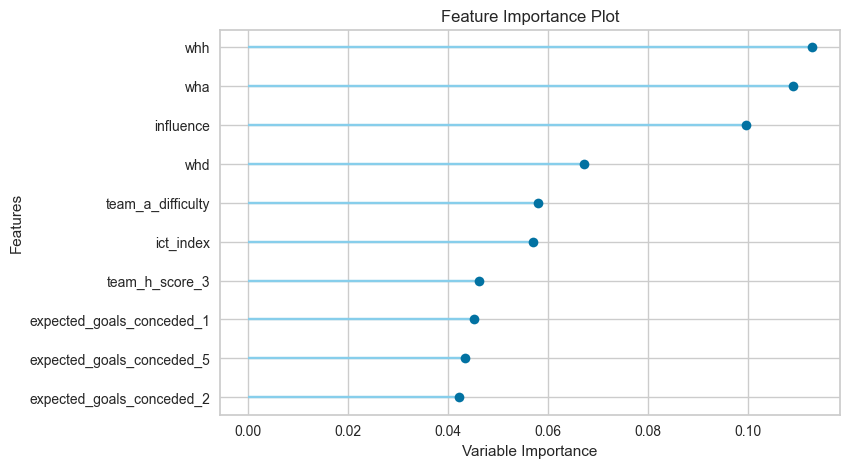

In [43]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [44]:
blend_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xgc_best = compare_models(n_select=3, sort='MAE')
print(def_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
def_xgc_blended = blend_models(def_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6273
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 71
[LightGBM] [Info] Start training from score -0.008124


,Description,Value
0,Session id,226
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6455, 108)"
4,Transformed data shape,"(6455, 22)"
5,Transformed train set shape,"(5164, 22)"
6,Transformed test set shape,"(1291, 22)"
7,Numeric features,106
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6304,0.6275,0.7906,0.3697,0.3833,1.5218,2.5140
lightgbm,Light Gradient Boosting Machine,0.6629,0.6858,0.8276,0.3118,0.3944,1.7144,0.8330
xgboost,Extreme Gradient Boosting,0.6678,0.7099,0.8418,0.2873,0.3796,1.8830,1.0970
rf,Random Forest Regressor,0.6732,0.7015,0.8370,0.2958,0.4091,1.5040,4.5690
gbr,Gradient Boosting Regressor,0.6963,0.7373,0.8582,0.2600,0.4221,1.5293,1.7100
ada,AdaBoost Regressor,0.7548,0.8473,0.9202,0.1496,0.4845,1.3307,1.1220
ridge,Ridge Regression,0.7651,0.8787,0.9371,0.1185,0.4575,1.5519,0.5910
lr,Linear Regression,0.7652,0.8790,0.9373,0.1181,0.4572,1.5534,0.8140
br,Bayesian Ridge,0.7667,0.8807,0.9382,0.1164,0.4615,1.5403,0.8010
en,Elastic Net,0.8039,0.9552,0.9770,0.0422,0.5339,1.2271,0.7670


[ExtraTreesRegressor(n_jobs=-1, random_state=226), LGBMRegressor(n_jobs=-1, random_state=226), XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=226, ...)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6485,0.6701,0.8186,0.3570,0.3907,1.8989
1,0.6750,0.6714,0.8194,0.2699,0.4131,1.5885
2,0.6230,0.6126,0.7827,0.4286,0.3593,1.7310
3,0.6495,0.6318,0.7948,0.3300,0.3963,1.3164
4,0.6116,0.5869,0.7661,0.4145,0.3702,1.9432
5,0.6283,0.6317,0.7948,0.3597,0.3700,1.3567
6,0.6706,0.7145,0.8453,0.2740,0.4084,1.2835
7,0.6013,0.5800,0.7616,0.3750,0.3589,1.6377
8,0.6922,0.7423,0.8616,0.3400,0.4321,1.3058


In [46]:
tuned_blend = tune_model(def_xgc_blended, optimize='MAE', n_iter=10)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6238,0.6375,0.7985,0.3883,0.3831,1.7638
1,0.6789,0.6776,0.8232,0.2631,0.4191,1.4824
2,0.6105,0.5884,0.7671,0.4511,0.3528,1.6584
3,0.6543,0.6348,0.7968,0.3267,0.4017,1.3001
4,0.5949,0.5614,0.7493,0.4399,0.3634,1.8880
5,0.6196,0.6179,0.7861,0.3736,0.3664,1.3301
6,0.6741,0.7142,0.8451,0.2743,0.4134,1.2842
7,0.5867,0.5575,0.7466,0.3993,0.3509,1.5759
8,0.7005,0.7413,0.8610,0.3409,0.4430,1.2855


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [47]:
def_xgc_final_model = finalize_model(tuned_blend)
save_model(def_xgc_final_model, 'def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                                            interaction_constraints=None,
                                                 